### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

/Users/waseem/Data/Projects/Learning/AI/GenAI/Langgrpah/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/waseem/Data/Projects/Learning/AI/GenAI/Langgrpah/venv/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [11]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="openai/gpt-oss-120b")

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

### We Will start With Creating Nodes

In [6]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

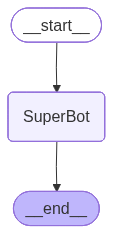

In [7]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [12]:
## Invocation

graph_builder.invoke({'messages':"I am learning LangGraph"})

{'messages': [HumanMessage(content='I am learning LangGraph', additional_kwargs={}, response_metadata={}, id='e7024998-9ee6-4350-b363-9dc1dac0d8dd'),
  AIMessage(content='Welcome to the world of **LangGraph**! 🎉  \nLangGraph is a lightweight, graph‑oriented framework that lets you build complex, stateful LLM applications (agents, workflows, decision trees, etc.) by wiring together “nodes” (LLM calls, tools, custom logic) and “edges” (the flow of information). If you’ve used LangChain before, you’ll find many familiar concepts—but LangGraph puts the focus on **explicit graph structures** and **state management**, making it easier to reason about and debug multi‑step interactions.\n\nBelow is a quick‑start guide, a roadmap of topics to explore, and a handful of resources to keep handy as you dive deeper.\n\n---\n\n## 1️⃣ High‑Level Overview\n\n| Concept | What It Is | Typical Use‑Case |\n|---------|------------|------------------|\n| **Node** | A unit of work: an LLM call, a tool invocat

#### Streaming The responses

In [10]:
for event in graph_builder.stream({"messages":"Hello My name is ALI"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='Hello, Ali! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond as per system instructions. The system says we are ChatGPT, must be helpful, etc. No special constraints. User says "Hello My name is ALI". We should greet and maybe ask how can help. Use friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 77, 'total_tokens': 154, 'completion_time': 0.174217951, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.002860741, 'prompt_tokens_details': None, 'queue_time': 0.049999399, 'total_time': 0.177078692}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019e5ef6-10ba-75e1-8155-6e7367496b3d-0', usage_metadata={'input_tokens': 77, 'output_tokens': 77, 'total_tokens': 154})]}}
